In [1]:

# import mercantile
# import requests
# from vt2geojson.tools import vt_bytes_to_geojson
# import geopandas as gpd
# import pandas as pd


# from shapely.geometry import box
# from shapely.geometry import shape


# #from osm2geojson import json2geojson

# import logging
# from datetime import datetime, timezone
# from tqdm import tqdm
# import json

# import os

# from pathlib import Path

In [2]:
import geopandas as gpd
import pandas as pd

import mercantile
from tqdm import tqdm
import json

from datetime import datetime, timezone
import requests

from vt2geojson.tools import vt_bytes_to_geojson


<Axes: >

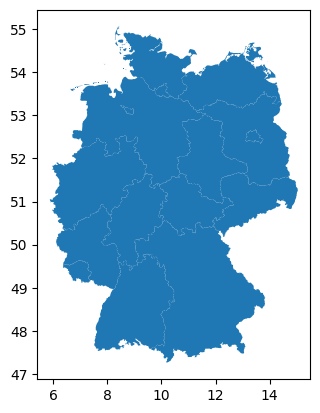

In [3]:


### get shape of Berlin
bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
#bland=bland[bland["id"].isin(["DE-BE"])]
bland.plot()



In [4]:


### get the number of tiles that would be downloaded

# Get the bounds of the polygon
polygon = bland.dissolve().geometry.iloc[0]
minx, miny, maxx, maxy = polygon.bounds

# === Define bounding box (Berlin or any area) ===
bbox = [minx, miny, maxx, maxy]  # must be defined earlier

# === Get intersecting tiles at zoom 14 ===
tiles = list(mercantile.tiles(*bbox, zooms=[14]))
total_tiles = len(tiles)

total_tiles



237424

In [5]:
polygon = bland.dissolve().geometry.iloc[0]

from shapely.geometry import box
import mercantile
from tqdm import tqdm  # Import tqdm

# Assuming `polygon` is your shapely Polygon (already from dissolve)
# `tiles` is your list of mercantile.Tile objects

filtered_tiles = []

for tile in tqdm(tiles):
    # Get tile bounds as a shapely box
    tile_bounds = mercantile.bounds(tile)
    tile_polygon = box(tile_bounds.west, tile_bounds.south, tile_bounds.east, tile_bounds.north)
    tile_centroid = tile_polygon.centroid

    # Check if the tile intersects the polygon
    if polygon.intersects(tile_centroid):
        filtered_tiles.append(tile)

100%|██████████| 237424/237424 [00:42<00:00, 5573.80it/s]


Text(0.5, 1.0, 'Berlin Boundary and mapillary tiles for polygon, n=151726')

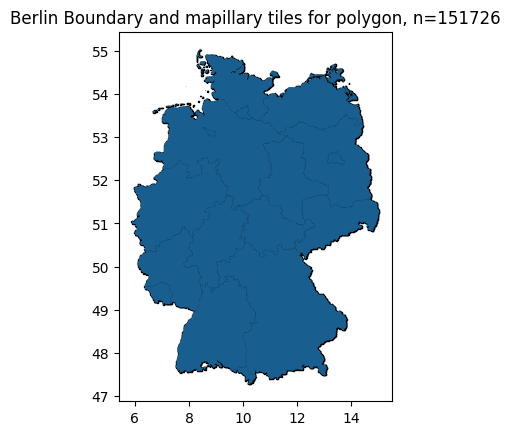

In [6]:


from shapely.geometry import Polygon
from shapely.geometry import MultiPolygon

# Create a list of polygons
polygons = []
for tile in filtered_tiles:
    minx, miny, maxx, maxy = mercantile.bounds(tile)
    polygons.append(Polygon([(minx, miny), (minx, maxy), (maxx, maxy), (maxx, miny)]))

# Combine the polygons into a single multi-polygon
multi_polygon = MultiPolygon(polygons)

gdf = gpd.GeoDataFrame(geometry=[multi_polygon])
#gdf.plot()

#bland.plot(ax=gdf.plot(color='green', edgecolor='black'), alpha=0.8)
ax = gdf.plot(color='green', edgecolor='black')
bland.plot(ax=ax, alpha=0.8)
ax.set_title("Ger Boundary and mapillary tiles for polygon, n="+str(len(filtered_tiles)))



In [7]:


# Load your access token
with open("config_mapillary_privat.json") as f:
    ACCESS_TOKEN = json.load(f)["ACCESS_TOKEN"]


# Get current date in YYYY-MM-DD format
current_date = datetime.now().strftime('%Y-%m-%d')

# Use existing variables
tile_layer = 'traffic_sign'  # already defined
tile_coverage = "mly_map_feature_traffic_sign"



# tiles is already defined and filtered
total_tiles = len(tiles)

#filetered_tiles_use = filtered_tiles[100:102]  
filetered_tiles_use = filtered_tiles

gdf_all = None

for i, tile in enumerate(tqdm(filetered_tiles_use, desc="Processing tiles"), start=1):
    url = f"https://tiles.mapillary.com/maps/vtp/{tile_coverage}/2/{tile.z}/{tile.x}/{tile.y}?access_token={ACCESS_TOKEN}"
    response = requests.get(url)
    
    if response.status_code != 200:
        continue

    try:
        geojson = vt_bytes_to_geojson(response.content, tile.x, tile.y, tile.z, layer=tile_layer)
        features = geojson.get("features", [])

        if not features:
            #print (f"No features found in tile {tile.x}/{tile.y}.")
            continue

        gdf_tile = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

        gdf_tile['first_seen_at'] = gdf_tile['first_seen_at'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc))
        gdf_tile['first_seen_at'] = gdf_tile['first_seen_at'].dt.strftime('%Y-%m-%d')
        gdf_tile['last_seen_at'] = gdf_tile['last_seen_at'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc))
        gdf_tile['last_seen_at'] = gdf_tile['last_seen_at'].dt.strftime('%Y-%m-%d')

        #gdf_tile['tile_x'] = tile.x
        #gdf_tile['tile_y'] = tile.y

        if gdf_all is None:
            gdf_all = gdf_tile
        else:
            gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, gdf_tile], ignore_index=True))
    except Exception as e:
        print (f"Error processing tile {tile.x}/{tile.y}: {e}")
      #  logging.warning(f"Error processing tile {tile.x}/{tile.y}: {e}")

#gdf_all

final_filename = f"mapillary_map-feature-data_ger_{current_date}.parquet"
gdf_all.to_parquet(final_filename, index=False)



Processing tiles:   0%|          | 0/151726 [00:00<?, ?it/s]

Processing tiles: 100%|██████████| 151726/151726 [28:21:48<00:00,  1.49it/s]   


In [9]:
gdf_all

,geometry,first_seen_at,id,last_seen_at,value
0,POINT (5.87278 51.04188),2017-07-26,937460437040493,2017-07-26,regulatory--keep-right--g1
1,POINT (5.87391 51.04213),2022-12-08,2275336505976951,2022-12-08,regulatory--yield--g1
2,POINT (5.87561 51.04201),2017-07-26,509836860046200,2017-07-26,information--bus-stop--g1
3,POINT (5.86728 51.04995),2019-08-19,308753427380748,2019-08-19,regulatory--priority-road--g1
4,POINT (5.87234 51.04163),2017-07-26,230466675518393,2017-07-26,regulatory--stop--g1
...,...,...,...,...,...
5348210,POINT (15.01171 51.24504),2020-08-20,325039229007548,2020-08-20,warning--wild-animals--g1
5348211,POINT (15.01546 51.23665),2020-09-18,793634861524984,2020-09-18,information--general-directions--g1
5348212,POINT (15.01098 51.24377),2020-08-20,505814950843393,2020-08-20,information--general-directions--g1
5348213,POINT (15.01041 51.2371),2020-08-20,300483418247452,2020-08-20,information--general-directions--g1


In [35]:
# gdf_all.explore(
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at"]
# )

In [ ]:
# Tempo 30 Schilder in 
gdf_all_t30=gdf_all[gdf_all.value=="regulatory--maximum-speed-limit-30--g1"]

In [ ]:
# Tempo 30 Schilder in xy, wenn sie mindest 2 mal im Abstand von 6 Monaten gesehen wurden


In [12]:
from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

df_6months = gdf_all_t30[
    gdf_all_t30.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 6, axis=1)
]
#df_6months[df_6months.value == "regulatory--maximum-speed-limit-30--g1"]

In [13]:
df_6months

,geometry,first_seen_at,id,last_seen_at,value
320,POINT (5.90068 51.01655),2022-04-13,1183592075719083,2025-05-02,regulatory--maximum-speed-limit-30--g1
1481,POINT (5.9377 50.99715),1970-01-01,538799025543412,2024-07-21,regulatory--maximum-speed-limit-30--g1
1545,POINT (5.93643 50.99792),1970-01-01,1017107176497479,2024-07-17,regulatory--maximum-speed-limit-30--g1
1612,POINT (5.94394 50.99439),2020-08-25,772382353479117,2024-04-23,regulatory--maximum-speed-limit-30--g1
1657,POINT (5.94374 50.99381),1970-01-01,916043223848347,2024-07-21,regulatory--maximum-speed-limit-30--g1
...,...,...,...,...,...
5345495,POINT (15.00238 51.15049),2016-08-30,263483918841981,2023-11-07,regulatory--maximum-speed-limit-30--g1
5347391,POINT (14.99721 51.15),2018-05-24,1149207125556695,2024-04-20,regulatory--maximum-speed-limit-30--g1
5347550,POINT (15.00137 51.1504),2016-08-30,953518088745891,2024-04-20,regulatory--maximum-speed-limit-30--g1
5347749,POINT (14.99938 51.15021),2016-08-30,741165849893276,2024-04-20,regulatory--maximum-speed-limit-30--g1


In [14]:
df_6months[df_6months.value == "regulatory--maximum-speed-limit-30--g1"].explore(
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at"]
)